<a href="https://colab.research.google.com/github/GuillermoUribe03/Coffee-Quality-Project/blob/main/Final_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# imports de librerias


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import kagglehub
from kagglehub import KaggleDatasetAdapter

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

# import dataset de kagle


In [18]:
file_path = "arabica_data_cleaned.csv"

df_raw = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "volpatto/coffee-quality-database-from-cqi",
  file_path,
)

Using Colab cache for faster access to the 'coffee-quality-database-from-cqi' dataset.


# Análisis exploratorio de los datos

### Filtrar las variables seleccionadas (excluimos atributos sensoriales)

In [12]:
AGRICULTURAL_FEATURES = [
    'Country.of.Origin',
    'Processing.Method',
    'Color',
    'altitude_mean_meters',
    'Category.One.Defects',
    'Category.Two.Defects',
    'Number.of.Bags',
    'Moisture',
]
TARGET = 'Total.Cup.Points'

df = df_raw[AGRICULTURAL_FEATURES + [TARGET]].copy()
print('Variables seleccionadas:', df.shape)
df.describe()

Variables seleccionadas: (1311, 9)


,altitude_mean_meters,Category.One.Defects,Category.Two.Defects,Number.of.Bags,Moisture,Total.Cup.Points
count,1084.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000
mean,1784.196379,0.426392,3.591915,153.887872,0.088863,82.115927
std,8767.016913,1.832415,5.350371,129.733734,0.047957,3.515761
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1100.000000,0.000000,0.000000,14.500000,0.090000,81.170000
50%,1310.640000,0.000000,2.000000,175.000000,0.110000,82.500000
75%,1600.000000,0.000000,4.000000,275.000000,0.120000,83.670000
max,190164.000000,31.000000,55.000000,1062.000000,0.280000,90.580000


### Análisis de valores que faltan

In [16]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, '% Faltantes': missing_pct})
print(missing_df[missing_df['Faltantes'] > 0])

                      Faltantes  % Faltantes
Country.of.Origin             1         0.08
Processing.Method           152        11.59
Color                       267        20.37
altitude_mean_meters        227        17.32


### Distribución de la variable objetivo

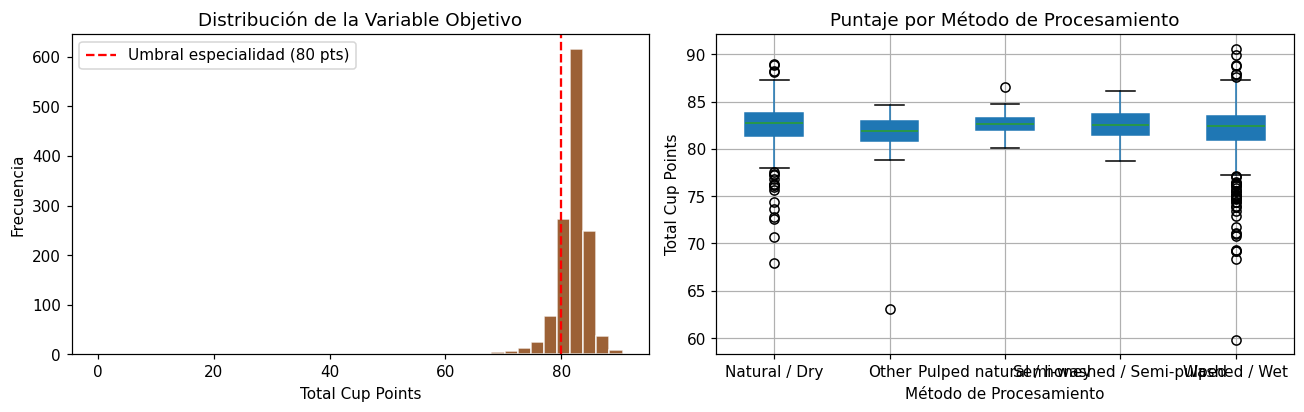

Estadísticos básicos de Total.Cup.Points:
count    1311.000000
mean       82.115927
std         3.515761
min         0.000000
25%        81.170000
50%        82.500000
75%        83.670000
max        90.580000
Name: Total.Cup.Points, dtype: float64


In [19]:
### Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET], bins=40, color='saddlebrown', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Total Cup Points')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de la Variable Objetivo')
axes[0].axvline(80, color='red', linestyle='--', label='Umbral especialidad (80 pts)')
axes[0].legend()

# Boxplot por método de procesamiento
order = df.groupby('Processing.Method')[TARGET].median().sort_values(ascending=False).index
df.boxplot(column=TARGET, by='Processing.Method', ax=axes[1],
           vert=True, patch_artist=True)
axes[1].set_xlabel('Método de Procesamiento')
axes[1].set_ylabel('Total Cup Points')
axes[1].set_title('Puntaje por Método de Procesamiento')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig1_distribucion_objetivo.png', bbox_inches='tight')
plt.show()
print(f"Estadísticos básicos de {TARGET}:")
print(df[TARGET].describe())

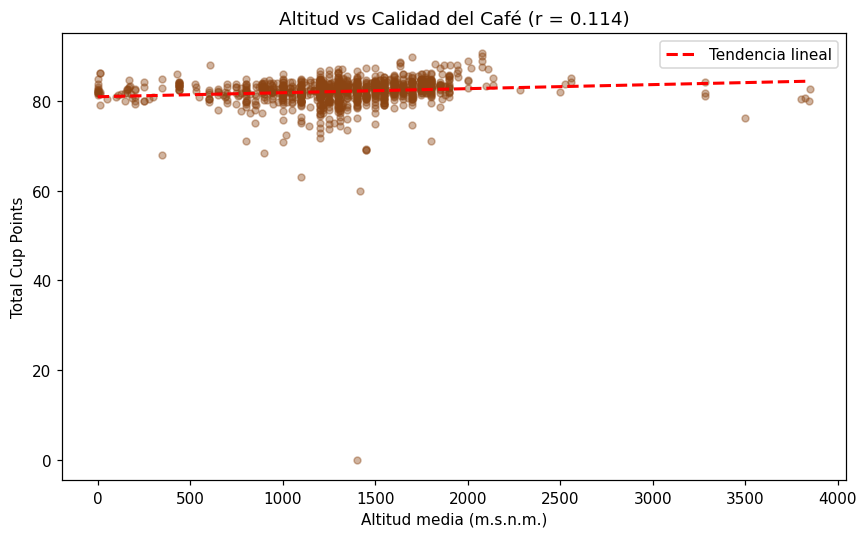

In [20]:
# Relación altitud vs puntaje
fig, ax = plt.subplots(figsize=(8, 5))
# Filtrar outliers de altitud
alt_mask = (df['altitude_mean_meters'] > 0) & (df['altitude_mean_meters'] < 4000)
ax.scatter(df.loc[alt_mask, 'altitude_mean_meters'],
           df.loc[alt_mask, TARGET],
           alpha=0.4, color='saddlebrown', s=20)
# Línea de tendencia
x = df.loc[alt_mask, 'altitude_mean_meters']
y = df.loc[alt_mask, TARGET]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
xs = np.linspace(x.min(), x.max(), 200)
ax.plot(xs, p(xs), 'r--', linewidth=2, label=f'Tendencia lineal')
corr = x.corr(y)
ax.set_xlabel('Altitud media (m.s.n.m.)')
ax.set_ylabel('Total Cup Points')
ax.set_title(f'Altitud vs Calidad del Café (r = {corr:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_altitud_vs_calidad.png', bbox_inches='tight')
plt.show()

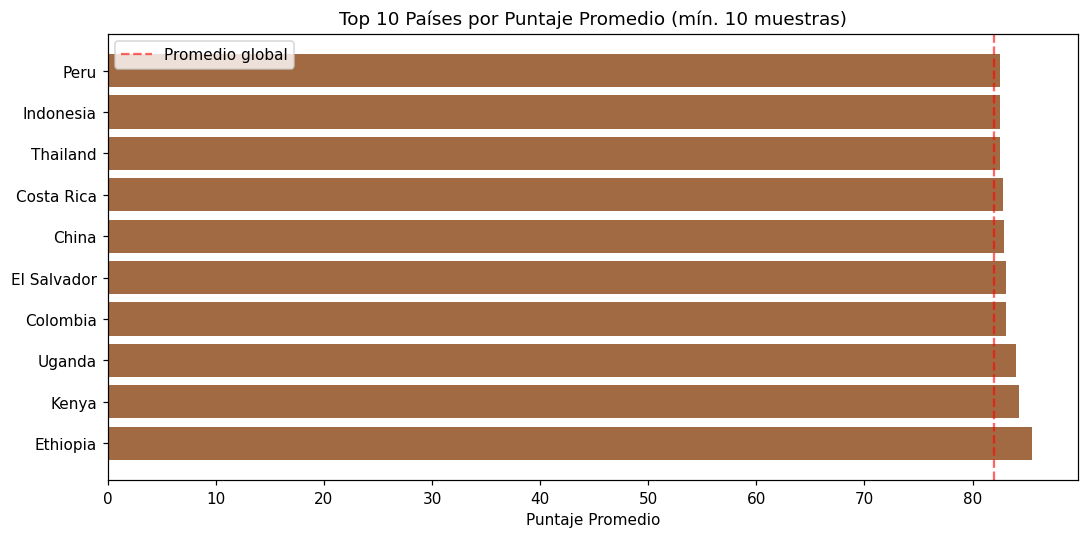

In [21]:
# Top 10 países por puntaje promedio
country_stats = df.groupby('Country.of.Origin')[TARGET].agg(['mean', 'count'])
country_stats = country_stats[country_stats['count'] >= 10].sort_values('mean', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(country_stats.index, country_stats['mean'], color='saddlebrown', alpha=0.8)
ax.set_xlabel('Puntaje Promedio')
ax.set_title('Top 10 Países por Puntaje Promedio (mín. 10 muestras)')
ax.axvline(82, color='red', linestyle='--', alpha=0.6, label='Promedio global')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_top_paises.png', bbox_inches='tight')
plt.show()

## 2. Preprocesamiento

In [22]:
# Eliminar fila con Total.Cup.Points == 0 (outlier obvio)
df = df[df[TARGET] > 50].copy()

# Separar X e y
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identificar tipos de columnas
CAT_COLS = ['Country.of.Origin', 'Processing.Method', 'Color']
NUM_COLS = ['altitude_mean_meters', 'Category.One.Defects',
            'Category.Two.Defects', 'Number.of.Bags', 'Moisture']

# Pipeline de preprocesamiento
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_COLS),
    ('cat', cat_transformer, CAT_COLS)
])

print(f'Dataset limpio: {X.shape[0]} muestras, {X.shape[1]} variables originales')

Dataset limpio: 1310 muestras, 8 variables originales


## 3. Reducción de Dimensión — Análisis Individual de Variables

Correlación de variables numéricas con la variable objetivo:
                      Correlación con Total Cup Points
Number.of.Bags                                0.036406
altitude_mean_meters                         -0.020927
Category.One.Defects                         -0.145318
Moisture                                     -0.148726
Category.Two.Defects                         -0.286653


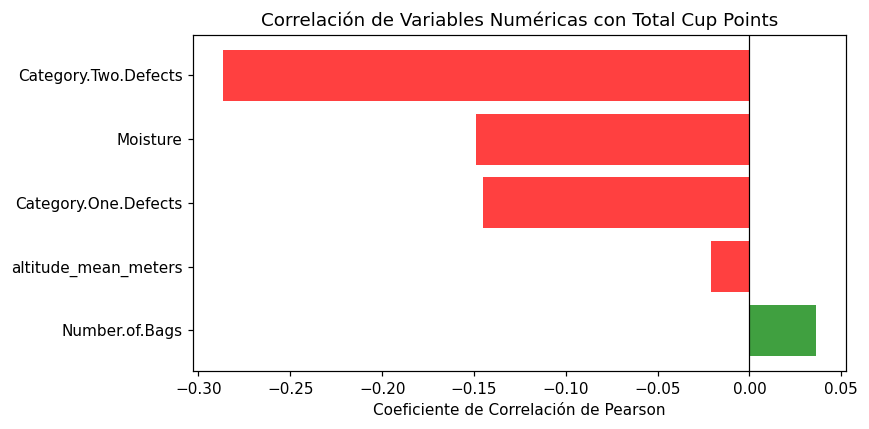

In [23]:
# Correlación de variables numéricas con el target
corr_df = df[NUM_COLS + [TARGET]].corr()[[TARGET]].drop(TARGET)
corr_df.columns = ['Correlación con Total Cup Points']
corr_df = corr_df.sort_values('Correlación con Total Cup Points', ascending=False)
print('Correlación de variables numéricas con la variable objetivo:')
print(corr_df)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if v > 0 else 'red' for v in corr_df.iloc[:, 0]]
ax.barh(corr_df.index, corr_df.iloc[:, 0], color=colors, alpha=0.75)
ax.set_xlabel('Coeficiente de Correlación de Pearson')
ax.set_title('Correlación de Variables Numéricas con Total Cup Points')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('fig4_correlaciones.png', bbox_inches='tight')
plt.show()

In [24]:
# Varianza de la variable objetivo por categoría (eta-cuadrado aproximado)
def eta_squared(groups, target):
    """Índice de discriminación eta^2 para variables categóricas."""
    grand_mean = target.mean()
    ss_total = ((target - grand_mean)**2).sum()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean)**2
        for g in [target[groups == cat] for cat in groups.unique()]
    )
    return ss_between / ss_total

for col in CAT_COLS:
    eta = eta_squared(df[col].fillna('Unknown'), y)
    print(f'{col:30s}  η² = {eta:.4f}')

Country.of.Origin               η² = 0.1978
Processing.Method               η² = 0.0187
Color                           η² = 0.0095


In [25]:
# Función de evaluación con IC bootstrap
def eval_model(estimator, X, y, cv=5, n_bootstrap=200):
    """
    Retorna métricas de CV + intervalos de confianza bootstrap.
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    results = cross_validate(
        estimator, X, y, cv=kf,
        scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
        return_train_score=True
    )
    rmse_scores = -results['test_neg_root_mean_squared_error']
    mae_scores  = -results['test_neg_mean_absolute_error']
    r2_scores   = results['test_r2']
    rmse_train  = -results['train_neg_root_mean_squared_error']

    def ci95(arr):
        boot = [np.mean(np.random.choice(arr, size=len(arr), replace=True))
                for _ in range(n_bootstrap)]
        return np.percentile(boot, [2.5, 97.5])

    return {
        'RMSE_val':   rmse_scores.mean(),
        'RMSE_ci':    ci95(rmse_scores),
        'MAE_val':    mae_scores.mean(),
        'R2_val':     r2_scores.mean(),
        'R2_ci':      ci95(r2_scores),
        'RMSE_train': rmse_train.mean(),
    }

print('Función de evaluación definida.')

Función de evaluación definida.


In [26]:
# ─── Definición de modelos y grillas de hiperparámetros ───
#
# Modelo 1: Ridge Regression (paramétrico / regresión lineal regularizada)
# Modelo 2: KNN Regressor (no paramétrico)
# Modelo 3: Random Forest (ensemble de árboles)
# Modelo 4: Gradient Boosting (ensemble de árboles, estilo XGBoost)
# Modelo 5: MLP Neural Network (red neuronal artificial)
# Modelo 6: SVR (máquina de vectores de soporte)

# Tabla de hiperparámetros analizados
HYPERPARAM_TABLE = pd.DataFrame([
    ['Ridge',             'alpha',           '0.01, 0.1, 1, 10, 100, 1000'],
    ['KNN',               'n_neighbors',     '3, 5, 7, 10, 15, 20'],
    ['KNN',               'weights',         'uniform, distance'],
    ['Random Forest',     'n_estimators',    '50, 100, 200'],
    ['Random Forest',     'max_depth',       'None, 5, 10, 20'],
    ['Random Forest',     'min_samples_leaf','1, 3, 5'],
    ['Gradient Boosting', 'n_estimators',    '50, 100, 200'],
    ['Gradient Boosting', 'learning_rate',   '0.01, 0.05, 0.1, 0.2'],
    ['Gradient Boosting', 'max_depth',       '3, 5, 7'],
    ['MLP',               'hidden_layer_sizes','(50,), (100,), (100,50), (100,100)'],
    ['MLP',               'alpha (L2)',      '0.0001, 0.001, 0.01'],
    ['MLP',               'learning_rate_init','0.001, 0.01'],
    ['SVR',               'C',               '0.1, 1, 10, 100'],
    ['SVR',               'epsilon',         '0.1, 0.5, 1.0'],
    ['SVR',               'kernel',          'rbf, linear'],
], columns=['Modelo', 'Hiperparámetro', 'Valores evaluados'])

In [27]:
# ─── GridSearchCV para cada modelo ───
# Se usa CV interno de 3-fold para búsqueda de hiperparámetros
# y CV externo de 5-fold para estimación del desempeño final.

def make_pipeline(model):
    return Pipeline([('prep', preprocessor), ('model', model)])

inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# 1. Ridge
ridge_gs = GridSearchCV(
    make_pipeline(Ridge()),
    param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 2. KNN
knn_gs = GridSearchCV(
    make_pipeline(KNeighborsRegressor()),
    param_grid={'model__n_neighbors': [3, 5, 7, 10, 15, 20],
                'model__weights': ['uniform', 'distance']},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 3. Random Forest
rf_gs = GridSearchCV(
    make_pipeline(RandomForestRegressor(random_state=42)),
    param_grid={'model__n_estimators': [100, 200],
                'model__max_depth': [None, 10, 20],
                'model__min_samples_leaf': [1, 3, 5]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 4. Gradient Boosting
gb_gs = GridSearchCV(
    make_pipeline(GradientBoostingRegressor(random_state=42)),
    param_grid={'model__n_estimators': [100, 200],
                'model__learning_rate': [0.05, 0.1, 0.2],
                'model__max_depth': [3, 5]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 5. MLP
mlp_gs = GridSearchCV(
    make_pipeline(MLPRegressor(max_iter=500, random_state=42, early_stopping=True)),
    param_grid={'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
                'model__alpha': [0.0001, 0.001, 0.01]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 6. SVR
svr_gs = GridSearchCV(
    make_pipeline(SVR()),
    param_grid={'model__C': [1, 10, 100],
                'model__epsilon': [0.1, 0.5, 1.0],
                'model__kernel': ['rbf', 'linear']},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

MODELS = {
    'Ridge (paramétrico)':          ridge_gs,
    'KNN (no paramétrico)':         knn_gs,
    'Random Forest (ensemble)':     rf_gs,
    'Gradient Boosting (ensemble)': gb_gs,
    'Red Neuronal (MLP)':           mlp_gs,
    'SVR':                          svr_gs,
}
print('Modelos y grillas de búsqueda configurados.')

Modelos y grillas de búsqueda configurados.
